In [1]:
import os
print(os.getcwd())

C:\Users\Aditi


In [5]:
import pandas as pd
df = pd.read_csv(r'C:\Users\Aditi\EC\ecommerce_sales_raw.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        320 non-null    int64  
 1   OrderDate      320 non-null    object 
 2   CustomerName   320 non-null    object 
 3   Region         320 non-null    object 
 4   Product        320 non-null    object 
 5   Category       320 non-null    object 
 6   Quantity       320 non-null    int64  
 7   UnitPrice      320 non-null    float64
 8   Discount       320 non-null    float64
 9   ShippingCost   320 non-null    float64
 10  PaymentMethod  320 non-null    object 
 11  OrderStatus    320 non-null    object 
 12  GrossRevenue   320 non-null    float64
 13  NetRevenue     320 non-null    float64
 14  Unnamed: 14    0 non-null      float64
 15  Unnamed: 15    2 non-null      object 
 16  Unnamed: 16    0 non-null      float64
 17  Unnamed: 17    2 non-null      object 
dtypes: float64

In [9]:

df = df.drop(columns=['Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17'], errors='ignore')


df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed')


print("New Shape:", df.shape)
print("\nUpdated Data Types:")
print(df.dtypes)

New Shape: (320, 14)

Updated Data Types:
OrderID                   int64
OrderDate        datetime64[ns]
CustomerName             object
Region                   object
Product                  object
Category                 object
Quantity                  int64
UnitPrice               float64
Discount                float64
ShippingCost            float64
PaymentMethod            object
OrderStatus              object
GrossRevenue            float64
NetRevenue              float64
dtype: object


In [10]:
print(df['Category'].unique())

['Running Shoes' 'Wireless Mouse' 'Backpack' 'Water Bottle' 'Phone Case'
 'Notebook Set' 'Yoga Mat' 'Coffee Mug' 'Usb Charger' 'Desk Lamp'
 'Bluetooth Speaker' 'Throw Pillow']


In [11]:
print("Unique Categories:")
print(df['Category'].unique())

print("\nUnique Products:")
print(df['Product'].unique())

Unique Categories:
['Running Shoes' 'Wireless Mouse' 'Backpack' 'Water Bottle' 'Phone Case'
 'Notebook Set' 'Yoga Mat' 'Coffee Mug' 'Usb Charger' 'Desk Lamp'
 'Bluetooth Speaker' 'Throw Pillow']

Unique Products:
['Running Shoes' 'Wireless Mouse' 'Backpack' 'Water Bottle' 'Phone Case'
 'Notebook Set' 'Yoga Mat' 'Coffee Mug' 'USB Charger' 'Desk Lamp'
 'Bluetooth Speaker' 'Throw Pillow']


In [12]:

df['Category'] = df['Category'].str.title()
df['Product'] = df['Product'].str.title()


print(df['Category'].unique())

['Running Shoes' 'Wireless Mouse' 'Backpack' 'Water Bottle' 'Phone Case'
 'Notebook Set' 'Yoga Mat' 'Coffee Mug' 'Usb Charger' 'Desk Lamp'
 'Bluetooth Speaker' 'Throw Pillow']


In [13]:
print(df['OrderStatus'].value_counts())

OrderStatus
Delivered     172
Shipped        52
Processing     36
Cancelled      32
Returned       28
Name: count, dtype: int64


In [14]:

df['Category'] = df['Category'].str.title()
df['Product'] = df['Product'].str.title()

print(df['OrderStatus'].value_counts())

OrderStatus
Delivered     172
Shipped        52
Processing     36
Cancelled      32
Returned       28
Name: count, dtype: int64


In [15]:
revenue_by_region = df.groupby('Region')['NetRevenue'].sum().reset_index()

revenue_by_region = revenue_by_region.sort_values(by='NetRevenue', ascending=False)

print(revenue_by_region)

  Region  NetRevenue
2  South   6374.0915
1  North   4282.0315
0   East   2558.0490
3   West   2545.8400


In [16]:
status_by_region = df.groupby(['Region', 'OrderStatus']).size().unstack(fill_value=0)
print(status_by_region)

OrderStatus  Cancelled  Delivered  Processing  Returned  Shipped
Region                                                          
East                 8         26           7         5        6
North                9         43          12        10       22
South                9         72          13        12       17
West                 6         31           4         1        7


In [17]:
status_by_region['Total'] = status_by_region.sum(axis=1)

status_by_region['Failure_Rate_%'] = ((status_by_region['Cancelled'] + status_by_region['Returned']) / status_by_region['Total']) * 100

print(status_by_region[['Total', 'Failure_Rate_%']].round(1).sort_values(by='Failure_Rate_%', ascending=False))

OrderStatus  Total  Failure_Rate_%
Region                            
East            52            25.0
North           96            19.8
South          123            17.1
West            49            14.3


In [18]:
category_metrics = df.groupby('Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Avg_Discount_Pct=('Discount', 'mean'),
    Total_NetRevenue=('NetRevenue', 'sum')
).reset_index()

category_metrics['Avg_Discount_Pct'] = (category_metrics['Avg_Discount_Pct'] * 100).round(1)

category_metrics = category_metrics.sort_values(by='Total_NetRevenue', ascending=False)

print(category_metrics)

             Category  Total_Quantity  Avg_Discount_Pct  Total_NetRevenue
6       Running Shoes              72               9.7          3893.351
0            Backpack              80               9.7          3296.250
1   Bluetooth Speaker              52               5.0          1714.650
11           Yoga Mat              75               6.0          1542.200
3           Desk Lamp              60               5.8          1048.125
10     Wireless Mouse              68               6.9          1015.365
9        Water Bottle              62               9.1           699.375
2          Coffee Mug              80               7.9           615.450
7        Throw Pillow              44               7.5           569.100
5          Phone Case              62               9.6           558.441
8         Usb Charger              50              11.5           488.880
4        Notebook Set              51               4.4           318.825


C:\Users\Aditi\AppData\Local\Temp\ipykernel_22196\3650467092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_metrics, x='Total_NetRevenue', y='Category', palette='viridis')


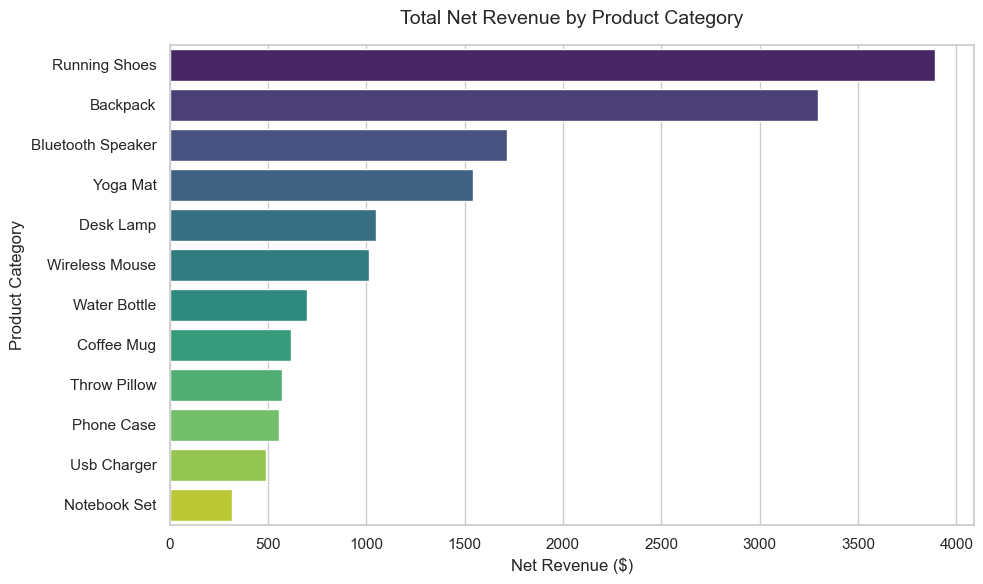

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(data=category_metrics, x='Total_NetRevenue', y='Category', palette='viridis')

plt.title('Total Net Revenue by Product Category', fontsize=14, pad=15)
plt.xlabel('Net Revenue ($)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\Aditi\AppData\Local\Temp\ipykernel_22196\3650467092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_metrics, x='Total_NetRevenue', y='Category', palette='viridis')


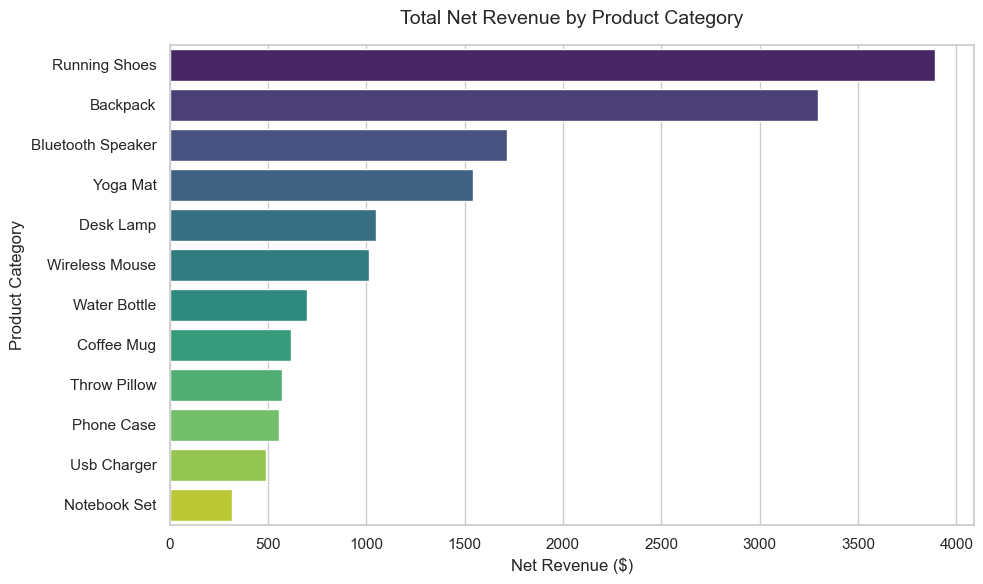

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(data=category_metrics, x='Total_NetRevenue', y='Category', palette='viridis')

plt.title('Total Net Revenue by Product Category', fontsize=14, pad=15)
plt.xlabel('Net Revenue ($)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

plt.tight_layout()
plt.show()

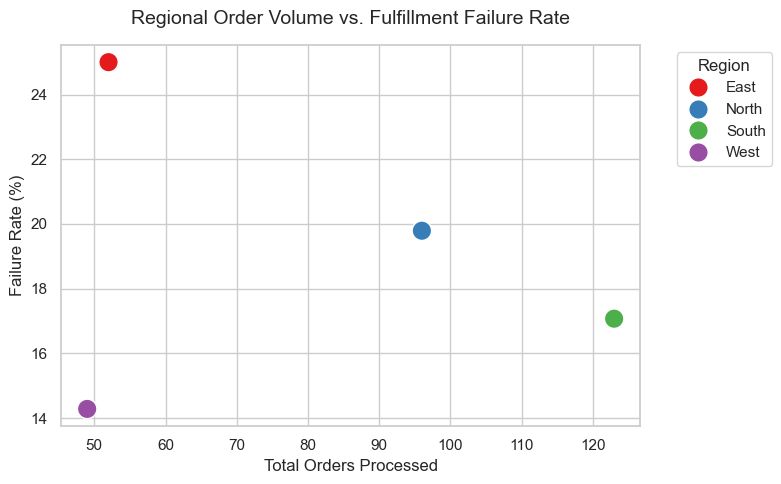

In [21]:
plot_data = status_by_region.reset_index()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_data, 
    x='Total', 
    y='Failure_Rate_%', 
    hue='Region', 
    s=200, # Marker size
    palette='Set1'
)

plt.title('Regional Order Volume vs. Fulfillment Failure Rate', fontsize=14, pad=15)
plt.xlabel('Total Orders Processed', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()